# 🏦 Banking Fraud Analytics & Fraud Prediction

## 1. Project Overview

### Business Problem
Banks process a large number of transactions every day. It is difficult to manually identify suspicious transactions and unusual customer behavior.

### Project Objective
This project analyzes banking transactions to:
- measure fraud rate and fraud amount
- understand fraudulent transaction patterns
- compare fraud across countries, cities, merchants and payment methods
- analyze customer-level fraud behavior
- identify unusual transactions using the **3-Sigma method**
- build a simple fraud prediction model
- provide business recommendations

### Tools
Python | Pandas | NumPy | Matplotlib | Seaborn | Scikit-learn | Jupyter Notebook

### Workflow
**Data Loading → Data Understanding → Data Quality → Data Cleaning → Fraud KPIs → Customer Analysis → 3-Sigma Outlier Analysis → Fraud Pattern Analysis → Visualization → Business Insights → Recommendations → ML Prediction**

# 2. Dataset Understanding

The dataset contains transaction-level banking information.

- **Rows:** 1,000,000
- **Columns:** 26
- **Target:** `is_fraud`

### Important columns

**Transaction:** `transaction_id`, `transaction_date`, `transaction_time`, `transaction_amount`

**Customer:** `customer_id`, `customer_age`, `credit_score`, `account_age_years`, `account_balance`

**Behavior:** `distance_from_home_km`, `num_prev_transactions`, `transaction_freq_monthly`, `time_since_last_txn_hrs`, `failed_attempts`

**Risk indicators:** `is_international`, `is_weekend`, `is_night_transaction`, `pin_changed_recently`

**Fraud:** `is_fraud`, `fraud_type`

# 3. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_transactions = pd.read_csv("bank_fraud.csv")

print("Rows and Columns:", df_transactions.shape)
df_transactions.head()

Rows and Columns: (1000000, 26)


,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,...,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,...,30.74,134,18,38.9,2.16,0,0,0,0,NaN


# 4. Data Dimensions & Initial Inspection

In [2]:
df_transactions.shape

(1000000, 26)

In [3]:
df_transactions.head(10)

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,...,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,...,30.74,134,18,38.9,2.16,0,0,0,0,NaN
5,TXN0000000006,CUST00110269,2024-06-26,04:28:00,4,0,1,Canada,Guadalajara,Crypto Exchange,...,35.36,157,19,23.0,31.46,0,2,0,1,Friendly Fraud
6,TXN0000000007,CUST00054887,2020-09-05,19:22:00,19,1,0,USA,Mumbai,Education,...,92.53,178,14,5.0,7.50,1,0,1,0,NaN
7,TXN0000000008,CUST00137338,2024-09-02,14:02:00,14,0,0,UK,Melbourne,Grocery,...,23.12,145,19,6.0,6.40,0,0,0,0,NaN
8,TXN0000000009,CUST00168267,2021-12-07,03:23:00,3,0,1,USA,Melbourne,Online Shopping,...,330.47,164,23,27.8,47.27,0,0,0,0,NaN
9,TXN0000000010,CUST00087499,2020-03-30,21:08:00,21,0,0,Mexico,Mumbai,Crypto Exchange,...,139.81,154,29,1.2,16.54,0,0,0,0,NaN


In [4]:
df_transactions.sample(5, random_state=42)

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
987231,TXN0000987232,CUST00115695,2021-07-14,00:12:00,0,0,1,Brazil,Rio,Clothing,...,108.03,161,16,58.3,1.34,0,0,0,0,NaN
79954,TXN0000079955,CUST00177167,2021-09-23,03:16:00,3,0,1,UK,Osaka,Crypto Exchange,...,24.13,156,11,3.3,1.97,0,2,0,1,Phishing
567130,TXN0000567131,CUST00171105,2021-03-23,14:34:00,14,0,0,UK,Munich,Jewelry,...,226.21,141,29,56.0,19.62,0,0,0,0,NaN
500891,TXN0000500892,CUST00029642,2023-04-11,16:41:00,16,0,0,Mexico,Sydney,Clothing,...,13.60,132,18,64.4,12.06,0,0,0,0,NaN
55399,TXN0000055400,CUST00055553,2024-06-28,23:47:00,23,0,1,USA,Rio,Crypto Exchange,...,55.77,172,22,6.0,8.15,1,2,0,0,NaN


In [5]:
df_transactions.tail(5)

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
999995,TXN0000999996,CUST00176672,2022-11-18,21:15:00,21,0,0,Mexico,Lyon,Electronics,...,1923.52,145,20,36.5,1.58,0,0,0,0,NaN
999996,TXN0000999997,CUST00005742,2021-07-03,22:57:00,22,1,1,Mexico,Tokyo,Online Shopping,...,146.16,154,17,20.0,2.10,0,0,0,0,NaN
999997,TXN0000999998,CUST00108137,2021-08-12,07:37:00,7,0,0,USA,Manchester,Grocery,...,27.38,148,20,3.4,2.74,0,1,0,0,NaN
999998,TXN0000999999,CUST00117141,2021-06-07,07:09:00,7,0,0,Japan,São Paulo,Electronics,...,365.30,150,16,63.1,3.71,1,1,0,0,NaN
999999,TXN0001000000,CUST00117401,2021-01-07,18:43:00,18,0,0,India,Berlin,Crypto Exchange,...,60.82,154,15,12.6,13.53,1,0,0,0,NaN


In [6]:
df_transactions.dtypes

transaction_id               object
customer_id                  object
transaction_date             object
transaction_time             object
hour_of_day                   int64
is_weekend                    int64
is_night_transaction          int64
country                      object
city                         object
merchant_category            object
payment_method               object
device_type                  object
customer_age                  int64
credit_score                  int64
account_age_years           float64
account_balance             float64
transaction_amount          float64
num_prev_transactions         int64
transaction_freq_monthly      int64
distance_from_home_km       float64
time_since_last_txn_hrs     float64
is_international              int64
failed_attempts               int64
pin_changed_recently          int64
is_fraud                      int64
fraud_type                   object
dtype: object

In [7]:
df_transactions.describe().T

,count,mean,std,min,25%,50%,75%,max
hour_of_day,1000000.0,11.496978,6.923751,0.0,5.0000,11.00,18.000,23.0
is_weekend,1000000.0,0.286022,0.451900,0.0,0.0000,0.00,1.000,1.0
is_night_transaction,1000000.0,0.375057,0.484138,0.0,0.0000,0.00,1.000,1.0
customer_age,1000000.0,41.771678,13.424588,18.0,32.0000,42.00,51.000,85.0
credit_score,1000000.0,679.028781,78.828748,300.0,625.0000,680.00,734.000,850.0
account_age_years,1000000.0,4.987911,4.925949,0.1,1.4000,3.50,6.900,30.0
account_balance,1000000.0,16594.254420,28171.460680,100.0,3609.0175,8092.12,18225.025,500000.0
transaction_amount,1000000.0,204.724665,459.567802,1.0,33.4000,73.12,181.450,46129.6
num_prev_transactions,1000000.0,149.996350,12.244379,96.0,142.0000,150.00,158.000,213.0
transaction_freq_monthly,1000000.0,19.999322,4.474045,2.0,17.0000,20.00,23.000,44.0


In [8]:
df_transactions.nunique()

transaction_id              1000000
customer_id                  198662
transaction_date               1826
transaction_time               1440
hour_of_day                      24
is_weekend                        2
is_night_transaction              2
country                          10
city                             20
merchant_category                15
payment_method                    6
device_type                       5
customer_age                     68
credit_score                    509
account_age_years               300
account_balance              828209
transaction_amount           114727
num_prev_transactions           114
transaction_freq_monthly         43
distance_from_home_km          1814
time_since_last_txn_hrs        8798
is_international                  2
failed_attempts                   6
pin_changed_recently              2
is_fraud                          2
fraud_type                        6
dtype: int64

# 5. Data Quality & Cleaning

Before analysis, we check missing values, duplicate records, data types, negative values and inconsistent fraud labels.

## 5.1 Missing Values

In [9]:
df_transactions.isnull().sum()

transaction_id                   0
customer_id                      0
transaction_date                 0
transaction_time                 0
hour_of_day                      0
is_weekend                       0
is_night_transaction             0
country                          0
city                             0
merchant_category                0
payment_method                   0
device_type                      0
customer_age                     0
credit_score                     0
account_age_years                0
account_balance                  0
transaction_amount               0
num_prev_transactions            0
transaction_freq_monthly         0
distance_from_home_km            0
time_since_last_txn_hrs          0
is_international                 0
failed_attempts                  0
pin_changed_recently             0
is_fraud                         0
fraud_type                  944745
dtype: int64

## 5.2 Duplicate Records

In [10]:
print("Duplicate rows:", df_transactions.duplicated().sum())
print("Duplicate transaction IDs:", df_transactions["transaction_id"].duplicated().sum())

Duplicate rows: 0
Duplicate transaction IDs: 0


**Note:** Repeated values inside columns such as country, merchant category or payment method are normal. They are not duplicate rows.

## 5.3 Data Types

In [11]:
df_transactions.dtypes

transaction_id               object
customer_id                  object
transaction_date             object
transaction_time             object
hour_of_day                   int64
is_weekend                    int64
is_night_transaction          int64
country                      object
city                         object
merchant_category            object
payment_method               object
device_type                  object
customer_age                  int64
credit_score                  int64
account_age_years           float64
account_balance             float64
transaction_amount          float64
num_prev_transactions         int64
transaction_freq_monthly      int64
distance_from_home_km       float64
time_since_last_txn_hrs     float64
is_international              int64
failed_attempts               int64
pin_changed_recently          int64
is_fraud                      int64
fraud_type                   object
dtype: object

## 5.4 Negative Values

In [12]:
numeric_cols = df_transactions.select_dtypes(include="number").columns

(df_transactions[numeric_cols] < 0).sum()

hour_of_day                 0
is_weekend                  0
is_night_transaction        0
customer_age                0
credit_score                0
account_age_years           0
account_balance             0
transaction_amount          0
num_prev_transactions       0
transaction_freq_monthly    0
distance_from_home_km       0
time_since_last_txn_hrs     0
is_international            0
failed_attempts             0
pin_changed_recently        0
is_fraud                    0
dtype: int64

## 5.5 Date and Time Conversion

In [13]:
df_transactions["transaction_date"] = pd.to_datetime(
    df_transactions["transaction_date"],
    errors="coerce"
)

df_transactions["transaction_time"] = pd.to_datetime(
    df_transactions["transaction_time"],
    format="%H:%M:%S",
    errors="coerce"
)

df_transactions["hour_of_day"] = df_transactions["transaction_time"].dt.hour

df_transactions[["transaction_date", "transaction_time", "hour_of_day"]].head()

,transaction_date,transaction_time,hour_of_day
0,2023-08-17,1900-01-01 21:13:00,21
1,2024-02-06,1900-01-01 05:16:00,5
2,2024-06-28,1900-01-01 12:15:00,12
3,2023-03-16,1900-01-01 02:53:00,2
4,2024-07-12,1900-01-01 12:39:00,12


## 5.6 Binary Columns

In [14]:
binary_cols = [
    "is_weekend",
    "is_night_transaction",
    "is_international",
    "pin_changed_recently",
    "is_fraud"
]

for col in binary_cols:
    df_transactions[col] = pd.to_numeric(
        df_transactions[col],
        errors="coerce"
    ).fillna(0).astype(int)

df_transactions[binary_cols].head()

,is_weekend,is_night_transaction,is_international,pin_changed_recently,is_fraud
0,0,0,0,0,0
1,0,1,0,0,0
2,0,0,0,0,0
3,0,1,1,1,1
4,0,0,0,0,0


## 5.7 Fraud Type Cleaning

In [15]:
df_transactions["fraud_type"] = df_transactions["fraud_type"].fillna("No Fraud")

df_transactions.loc[
    df_transactions["is_fraud"] == 0,
    "fraud_type"
] = "No Fraud"

df_transactions["fraud_type"].value_counts()

fraud_type
No Fraud              944745
Phishing                9252
Account Takeover        9232
Synthetic Identity      9214
Card Cloning            9200
Friendly Fraud          9187
Identity Theft          9170
Name: count, dtype: int64

### Outlier Decision

For this project, outliers are **not automatically deleted**.

In fraud analysis, an unusually large transaction or unusual customer behavior may itself be an important fraud signal.

Therefore, outliers will be analyzed separately using the **3-Sigma method**.

In [16]:
print("Final shape:", df_transactions.shape)
print("Total missing values:", df_transactions.isnull().sum().sum())

Final shape: (1000000, 26)
Total missing values: 0


# 6. Customer Risk Analysis

Customer-level analysis helps identify customers with repeated fraud activity or unusual transaction behavior.

In [17]:
customer_summary = df_transactions.groupby("customer_id").agg(
    total_transactions=("transaction_id", "count"),
    total_amount=("transaction_amount", "sum"),
    average_amount=("transaction_amount", "mean"),
    fraud_transactions=("is_fraud", "sum"),
    fraud_rate=("is_fraud", "mean")
)

customer_summary["fraud_rate"] = customer_summary["fraud_rate"] * 100

customer_summary.sort_values(
    "fraud_rate",
    ascending=False
).head(10)

,total_transactions,total_amount,average_amount,fraud_transactions,fraud_rate
customer_id,,,,,
CUST00010686,2,649.05,324.525,2,100.0
CUST00198969,1,65.24,65.240,1,100.0
CUST00198914,1,31.33,31.330,1,100.0
CUST00136882,1,556.11,556.110,1,100.0
CUST00136869,1,12.98,12.980,1,100.0
CUST00136779,1,9.01,9.010,1,100.0
CUST00134991,1,71.59,71.590,1,100.0
CUST00134952,1,52.62,52.620,1,100.0
CUST00137768,1,35.54,35.540,1,100.0


# 7. Fraud Behavior & Outlier Analysis

## 3-Sigma Outlier Method

The 3-Sigma method identifies observations outside:

**Mean ± 3 × Standard Deviation**

We use this method for selected numerical transaction-behavior variables.

### Variables
- Transaction Amount
- Distance from Home
- Transaction Frequency
- Previous Transactions

The purpose is to compare unusual transactions with normal transactions.

## 7.1 Transaction Amount — 3 Sigma

In [18]:
avg = df_transactions["transaction_amount"].mean()
std = df_transactions["transaction_amount"].std()

higher_limit = avg + 3 * std
lower_limit = avg - 3 * std

print("Mean:", avg)
print("Standard Deviation:", std)
print("Lower Limit:", lower_limit)
print("Upper Limit:", higher_limit)

Mean: 204.72466542
Standard Deviation: 459.56780201034917
Lower Limit: -1173.9787406110474
Upper Limit: 1583.4280714510476


In [19]:
high_value = df_transactions[
    df_transactions["transaction_amount"] > higher_limit
]

normal_value = df_transactions[
    (df_transactions["transaction_amount"] >= lower_limit) &
    (df_transactions["transaction_amount"] <= higher_limit)
]

print("High-value transactions:", len(high_value))
print("Normal transactions:", len(normal_value))

High-value transactions: 17388
Normal transactions: 982612


In [20]:
print("Fraud rate in high-value transactions:",
      high_value["is_fraud"].mean() * 100)

print("Fraud rate in normal transactions:",
      normal_value["is_fraud"].mean() * 100)

Fraud rate in high-value transactions: 6.81504485852312
Fraud rate in normal transactions: 5.5026806104545845


In [21]:
high_value[high_value["is_fraud"] == 1]["fraud_type"].value_counts()

fraud_type
Friendly Fraud        214
Account Takeover      213
Card Cloning          211
Synthetic Identity    192
Phishing              181
Identity Theft        174
Name: count, dtype: int64

In [22]:
normal_value[normal_value["is_fraud"] == 1]["fraud_type"].value_counts()

fraud_type
Phishing              9071
Synthetic Identity    9022
Account Takeover      9019
Identity Theft        8996
Card Cloning          8989
Friendly Fraud        8973
Name: count, dtype: int64

## 7.2 Distance from Home — 3 Sigma

In [23]:
avg = df_transactions["distance_from_home_km"].mean()
std = df_transactions["distance_from_home_km"].std()

higher_limit = avg + 3 * std
lower_limit = avg - 3 * std

distance_outlier = df_transactions[
    (df_transactions["distance_from_home_km"] < lower_limit) |
    (df_transactions["distance_from_home_km"] > higher_limit)
]

distance_normal = df_transactions[
    (df_transactions["distance_from_home_km"] >= lower_limit) &
    (df_transactions["distance_from_home_km"] <= higher_limit)
]

print("Distance outliers:", len(distance_outlier))
print("Normal transactions:", len(distance_normal))

print("Outlier fraud rate:",
      distance_outlier["is_fraud"].mean() * 100)

print("Normal fraud rate:",
      distance_normal["is_fraud"].mean() * 100)

Distance outliers: 18228
Normal transactions: 981772
Outlier fraud rate: 5.403774412991003
Normal fraud rate: 5.5277600094522965


## 7.3 Transaction Frequency — 3 Sigma

In [24]:
avg = df_transactions["transaction_freq_monthly"].mean()
std = df_transactions["transaction_freq_monthly"].std()

higher_limit = avg + 3 * std
lower_limit = avg - 3 * std

frequency_outlier = df_transactions[
    (df_transactions["transaction_freq_monthly"] < lower_limit) |
    (df_transactions["transaction_freq_monthly"] > higher_limit)
]

frequency_normal = df_transactions[
    (df_transactions["transaction_freq_monthly"] >= lower_limit) &
    (df_transactions["transaction_freq_monthly"] <= higher_limit)
]

print("Frequency outliers:", len(frequency_outlier))
print("Outlier fraud rate:",
      frequency_outlier["is_fraud"].mean() * 100)

print("Normal fraud rate:",
      frequency_normal["is_fraud"].mean() * 100)

Frequency outliers: 2910
Outlier fraud rate: 5.120274914089347
Normal fraud rate: 5.526682646501318


## 7.4 Previous Transactions — 3 Sigma

In [25]:
avg = df_transactions["num_prev_transactions"].mean()
std = df_transactions["num_prev_transactions"].std()

higher_limit = avg + 3 * std
lower_limit = avg - 3 * std

previous_outlier = df_transactions[
    (df_transactions["num_prev_transactions"] < lower_limit) |
    (df_transactions["num_prev_transactions"] > higher_limit)
]

previous_normal = df_transactions[
    (df_transactions["num_prev_transactions"] >= lower_limit) &
    (df_transactions["num_prev_transactions"] <= higher_limit)
]

print("Previous-transaction outliers:", len(previous_outlier))
print("Outlier fraud rate:",
      previous_outlier["is_fraud"].mean() * 100)

print("Normal fraud rate:",
      previous_normal["is_fraud"].mean() * 100)

Previous-transaction outliers: 2874
Outlier fraud rate: 5.567153792623522
Normal fraud rate: 5.525379941953173


### 3-Sigma Interpretation

A 3-Sigma outlier is a statistically unusual observation.

**It does not automatically mean fraud.**

The correct business approach is to compare the fraud rate of outlier transactions with normal transactions and investigate whether unusual behavior is associated with higher fraud risk.

# 8. Fraud Pattern Analysis

Now we analyze fraud rate across major business dimensions.

## 8.1 Merchant Category

In [26]:
merchant_fraud = (
    df_transactions.groupby("merchant_category")["is_fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

merchant_fraud

merchant_category
ATM Withdrawal     8.739400
Jewelry            8.704950
Crypto Exchange    8.652048
Fuel               4.838203
Electronics        4.830557
Education          4.781789
Clothing           4.765541
Online Shopping    4.731614
Gaming             4.724291
Healthcare         4.718298
Restaurant         4.708231
Travel             4.706711
Entertainment      4.692480
Grocery            4.692316
Utilities          4.621415
Name: is_fraud, dtype: float64

## 8.2 Payment Method

In [27]:
payment_fraud = (
    df_transactions.groupby("payment_method")["is_fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

payment_fraud

payment_method
Cheque            5.668399
Credit Card       5.596966
Bank Transfer     5.506269
Crypto            5.498624
Mobile Payment    5.487188
Debit Card        5.457688
Name: is_fraud, dtype: float64

## 8.3 Country

In [28]:
country_fraud = (
    df_transactions.groupby("country")["is_fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

country_fraud

country
Brazil       5.665144
Canada       5.561928
Germany      5.541707
USA          5.540662
UK           5.516819
Australia    5.514250
India        5.490575
Japan        5.484474
Mexico       5.466611
France       5.417436
Name: is_fraud, dtype: float64

## 8.4 City

In [29]:
city_fraud = (
    df_transactions.groupby("city")["is_fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

city_fraud.head(15)

city
Paris          5.625338
Los Angeles    5.617035
Rio            5.611039
New York       5.606479
Munich         5.592814
Delhi          5.565099
Tokyo          5.562823
Vancouver      5.547082
Osaka          5.546786
Toronto        5.542785
Mexico City    5.541446
London         5.540886
Berlin         5.521890
Guadalajara    5.507471
Melbourne      5.479942
Name: is_fraud, dtype: float64

## 8.5 Device Type

In [30]:
device_fraud = (
    df_transactions.groupby("device_type")["is_fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

device_fraud

device_type
ATM             5.605228
Mobile          5.571859
Desktop         5.469719
Tablet          5.464481
POS Terminal    5.437175
Name: is_fraud, dtype: float64

## 8.6 Fraud Type

In [31]:
fraud_type = (
    df_transactions[df_transactions["is_fraud"] == 1]
    ["fraud_type"]
    .value_counts()
)

fraud_type

fraud_type
Phishing              9252
Account Takeover      9232
Synthetic Identity    9214
Card Cloning          9200
Friendly Fraud        9187
Identity Theft        9170
Name: count, dtype: int64

## 8.7 Fraud by Hour

In [32]:
hour_fraud = (
    df_transactions.groupby("hour_of_day")["is_fraud"]
    .mean()
    .mul(100)
)

hour_fraud

hour_of_day
0     7.833230
1     8.068583
2     7.932345
3     7.905468
4     7.899835
5     8.018812
6     8.073860
7     3.956878
8     4.244057
9     4.362311
10    4.010025
11    4.159262
12    4.009219
13    3.886477
14    3.981597
15    4.002686
16    4.067294
17    3.989977
18    4.232677
19    3.985083
20    4.045176
21    4.074039
22    7.993655
23    7.877647
Name: is_fraud, dtype: float64

## 8.8 Weekend / Night / International

In [33]:
weekend_fraud = (
    df_transactions.groupby("is_weekend")["is_fraud"]
    .mean()
    .mul(100)
)

night_fraud = (
    df_transactions.groupby("is_night_transaction")["is_fraud"]
    .mean()
    .mul(100)
)

international_fraud = (
    df_transactions.groupby("is_international")["is_fraud"]
    .mean()
    .mul(100)
)

print("Weekend:")
display(weekend_fraud)

print("Night:")
display(night_fraud)

print("International:")
display(international_fraud)

Weekend:


is_weekend
0    5.508293
1    5.568453
Name: is_fraud, dtype: float64

Night:


is_night_transaction
0    4.066931
1    7.955857
Name: is_fraud, dtype: float64

International:


is_international
0    4.761261
1    9.856394
Name: is_fraud, dtype: float64

# 9. Fraud Overview & KPI Analysis

These KPIs provide the overall fraud picture.

In [34]:
total_transactions = len(df_transactions)
total_fraud = df_transactions["is_fraud"].sum()
total_non_fraud = total_transactions - total_fraud

fraud_rate = df_transactions["is_fraud"].mean() * 100

fraud_amount = df_transactions[
    df_transactions["is_fraud"] == 1
]["transaction_amount"].sum()

avg_fraud_amount = df_transactions[
    df_transactions["is_fraud"] == 1
]["transaction_amount"].mean()

fraud_customers = df_transactions[
    df_transactions["is_fraud"] == 1
]["customer_id"].nunique()

print("Total Transactions:", total_transactions)
print("Fraud Transactions:", total_fraud)
print("Non-Fraud Transactions:", total_non_fraud)
print(f"Fraud Rate: {fraud_rate:.2f}%")
print(f"Total Fraud Amount: ${fraud_amount:,.2f}")
print(f"Average Fraud Amount: ${avg_fraud_amount:,.2f}")
print("Fraud Customers:", fraud_customers)

Total Transactions: 1000000
Fraud Transactions: 55255
Non-Fraud Transactions: 944745
Fraud Rate: 5.53%
Total Fraud Amount: $12,602,509.65
Average Fraud Amount: $228.08
Fraud Customers: 48121


# 10. Key Business Insights

The analysis identified several transaction characteristics associated with higher fraud rates. These insights can support risk-based transaction monitoring and fraud prevention strategies.

### 10.1 International Transactions Show Higher Fraud Risk

> **Finding:** International transactions recorded a fraud rate of approximately **9.86%**, compared with **4.76%** for non-international transactions.
>
> **Business Meaning:** International transactions showed approximately **2× higher fraud activity** than non-international transactions in this dataset.
>
> **Business Suggestion:** Banks can apply additional verification or risk scoring to international transactions, especially when combined with other suspicious signals.

---

### 10.2 Night Transactions Show Elevated Fraud Activity

> **Finding:** Night transactions had a fraud rate of approximately **7.96%**, compared with **4.07%** for non-night transactions.
>
> **Business Meaning:** Fraud activity was substantially higher during night transactions, indicating that transaction timing can be an important risk indicator.
>
> **Business Suggestion:** Implement stronger monitoring for night transactions and combine time-based signals with transaction amount, location and customer behavior.

---

### 10.3 ATM Withdrawal Is the Highest-Risk Merchant Category

> **Finding:** **ATM Withdrawal** recorded the highest fraud rate at approximately **8.74%**, followed by **Jewelry at 8.70%** and **Crypto Exchange at 8.65%**.
>
> **Business Meaning:** These merchant categories showed considerably higher fraud activity than many other categories in the dataset.
>
> **Business Suggestion:** Apply enhanced monitoring and transaction verification for high-risk merchant categories, particularly when multiple risk indicators are present.

---

### 10.4 Early-Morning Transactions Show Higher Fraud Rates

> **Finding:** Fraud rates were elevated during the early-morning period. The highest hourly fraud rate was approximately **8.07% at 6 AM**, while several hours from midnight to early morning also showed elevated fraud rates.
>
> **Business Meaning:** Transaction time can provide an additional signal for identifying potentially unusual activity.
>
> **Business Suggestion:** Use time-based risk rules as one component of fraud monitoring rather than blocking transactions based on transaction time alone.

---

### 10.5 Payment Method Shows Differences in Fraud Activity

> **Finding:** **Cheque** transactions recorded the highest fraud rate at approximately **5.67%**, followed by **Credit Card at 5.60%**.
>
> **Business Meaning:** Fraud rates vary across payment methods, although the difference between the top payment methods is relatively small.
>
> **Business Suggestion:** Payment method should be combined with other transaction-level risk indicators instead of being used as a standalone fraud rule.

---

### 10.6 Weekend Status Shows Limited Difference

> **Finding:** Weekend transactions had a fraud rate of approximately **5.57%**, compared with **5.51%** for non-weekend transactions.
>
> **Business Meaning:** The difference is very small, indicating that weekend status alone may provide limited fraud-detection value in this dataset.
>
> **Business Suggestion:** Weekend status should not be treated as a major standalone fraud indicator. It can instead be combined with stronger signals such as international transactions, night activity and unusual transaction behavior.

---

### 10.7 Unusual Transaction Behavior — 3-Sigma Analysis

> **Finding:** 3-Sigma analysis was used to identify statistically unusual transaction behavior across transaction amount, distance from home, transaction frequency and previous transactions.
>
> **Business Meaning:** A 3-Sigma outlier does not automatically represent fraud. The important comparison is whether outlier transactions have a higher fraud rate than normal transactions.
>
> **Business Suggestion:** Use statistically unusual transaction behavior as an additional risk signal, especially when combined with international activity, night transactions, failed attempts or high-risk merchant categories.

---

### 10.8 Customer-Level Fraud Monitoring

> **Finding:** Customer-level analysis was performed using total transactions, transaction amount, average transaction amount, fraud transaction count and fraud rate.
>
> **Business Meaning:** Repeated fraudulent activity at the customer level can indicate a pattern that requires further investigation.
>
> **Business Suggestion:** Banks can create customer-level risk monitoring by considering both **fraud frequency and transaction volume**, rather than relying only on fraud rate.

---

## Overall Business Takeaway

> **Finding:** Fraud activity varies across merchant categories, transaction timing, payment methods, geography and transaction characteristics. The strongest differences observed in this analysis were associated with **international transactions, night transactions and selected merchant categories such as ATM Withdrawal, Jewelry and Crypto Exchange**.
>
> **Business Meaning:** Fraud detection can be improved by using a **risk-based approach** that combines multiple transaction signals rather than relying on a single attribute.
>
> **Business Suggestion:** A practical fraud monitoring system can combine transaction amount, merchant category, international status, transaction time, customer behavior and failed attempts to prioritize transactions for further review.


# 11. Data Visualization

Only the most useful charts are included so the notebook remains clean and business-focused.

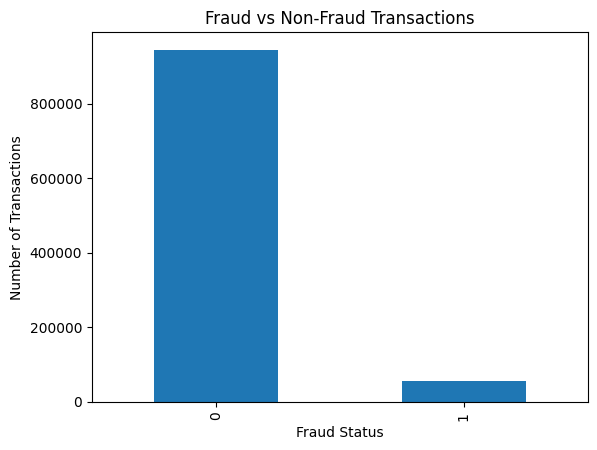

In [35]:
df_transactions["is_fraud"].value_counts().plot(kind="bar")

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")
plt.show()

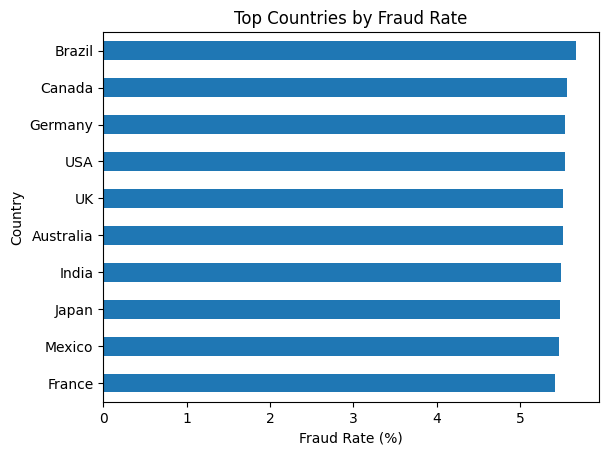

In [36]:
country_fraud.head(10).sort_values().plot(kind="barh")

plt.title("Top Countries by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Country")
plt.show()

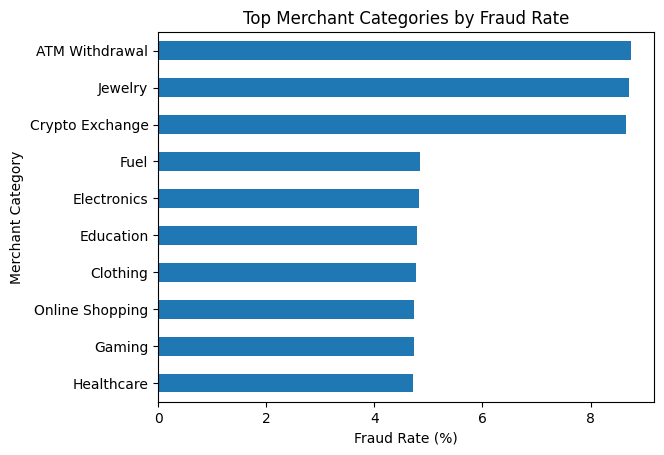

In [37]:
merchant_fraud.head(10).sort_values().plot(kind="barh")

plt.title("Top Merchant Categories by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Merchant Category")
plt.show()

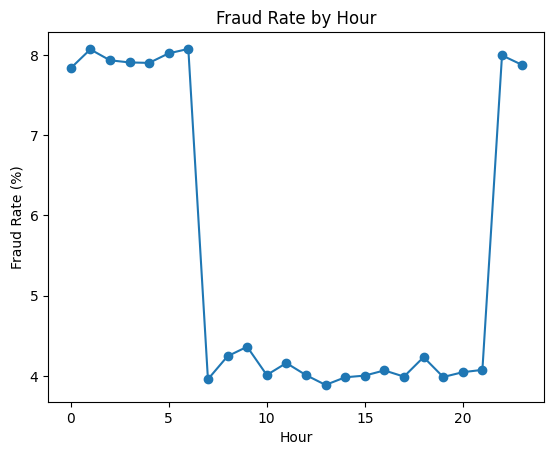

In [38]:
hour_fraud.plot(marker="o")

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.show()

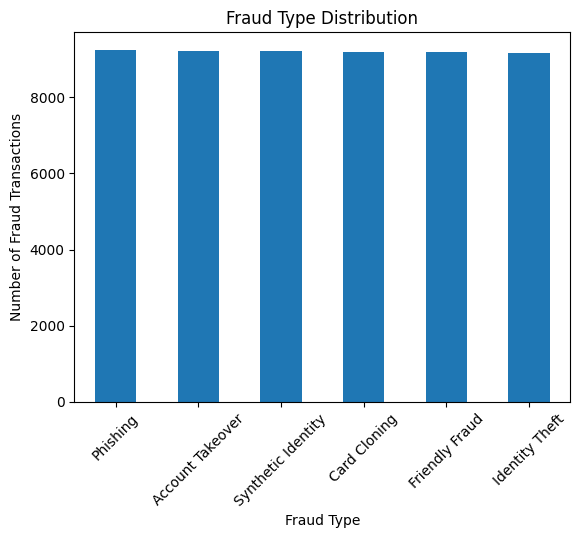

In [39]:
fraud_type.plot(kind="bar")

plt.title("Fraud Type Distribution")
plt.xlabel("Fraud Type")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(rotation=45)
plt.show()

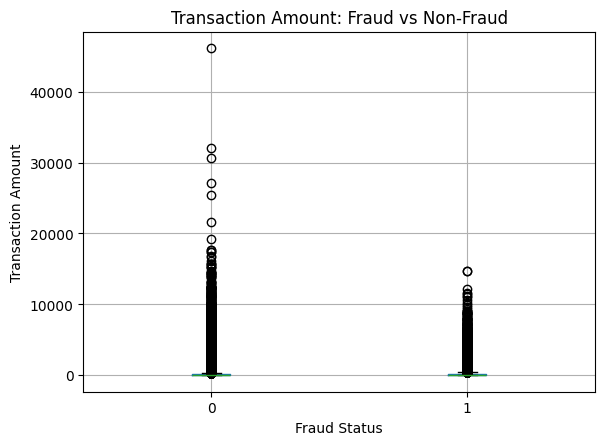

In [40]:
df_transactions.boxplot(
    column="transaction_amount",
    by="is_fraud"
)

plt.title("Transaction Amount: Fraud vs Non-Fraud")
plt.suptitle("")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount")
plt.show()

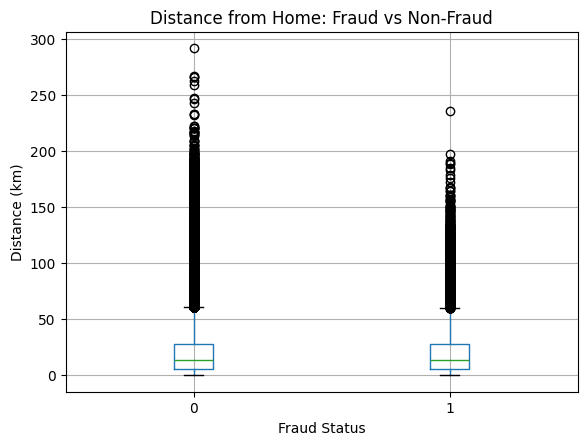

In [41]:
df_transactions.boxplot(
    column="distance_from_home_km",
    by="is_fraud"
)

plt.title("Distance from Home: Fraud vs Non-Fraud")
plt.suptitle("")
plt.xlabel("Fraud Status")
plt.ylabel("Distance (km)")
plt.show()

# 12. Business Recommendations

Based on the fraud pattern and risk analysis, the following business actions are recommended:

### 1. Risk-Based International Transaction Monitoring
Apply additional verification to international transactions because they showed substantially higher fraud activity than non-international transactions.

### 2. Enhanced Monitoring for High-Risk Merchant Categories
Prioritize monitoring for **ATM Withdrawal, Jewelry and Crypto Exchange** transactions where higher fraud rates were observed.

### 3. Time-Based Fraud Monitoring
Increase monitoring during early-morning and other higher-risk hours identified through hourly fraud analysis.

### 4. Customer-Level Risk Monitoring
Track customers with repeated fraud transactions while considering transaction volume to avoid misleading conclusions from very small transaction counts.

### 5. Monitor Unusual Transaction Behavior
Use **3-Sigma analysis** to identify statistically unusual transaction amounts and behavioral patterns for further investigation.

### 6. Combine Multiple Risk Signals
Avoid relying on a single factor. Combine transaction amount, international status, night activity, merchant category, failed attempts and customer behavior.

### 7. Use Fraud Prediction as a Decision-Support Layer
The machine learning model can be used as an additional risk-scoring layer to prioritize suspicious transactions for review rather than treating model predictions as the only decision factor.


# 13. Fraud Prediction Using Machine Learning

A simple classification model is used to estimate whether a transaction is fraudulent.

## 13.1 Feature Selection

In [42]:
features = [
    "transaction_amount",
    "hour_of_day",
    "distance_from_home_km",
    "num_prev_transactions",
    "transaction_freq_monthly",
    "failed_attempts",
    "account_balance",
    "is_weekend",
    "is_night_transaction",
    "is_international",
    "pin_changed_recently"
]

X = df_transactions[features]
y = df_transactions["is_fraud"]

print("Features:", features)

Features: ['transaction_amount', 'hour_of_day', 'distance_from_home_km', 'num_prev_transactions', 'transaction_freq_monthly', 'failed_attempts', 'account_balance', 'is_weekend', 'is_night_transaction', 'is_international', 'pin_changed_recently']


## 13.2 Train-Test Split

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 13.3 Logistic Regression

In [44]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

C:\Users\atish\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 13.4 Model Evaluation

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.67525
Precision: 0.09705297468638328
Recall   : 0.5873676590353815
F1 Score : 0.16658112200379818
ROC-AUC  : 0.6894410799003912


In [46]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.97      0.68      0.80    188949
           1       0.10      0.59      0.17     11051

    accuracy                           0.68    200000
   macro avg       0.53      0.63      0.48    200000
weighted avg       0.92      0.68      0.76    200000



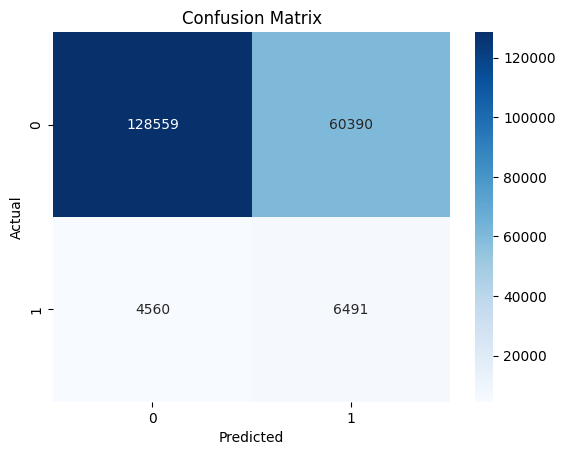

In [47]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### ML Interpretation

For fraud detection, do not judge the model only by Accuracy.

- **Precision:** How many flagged transactions were actually fraud?
- **Recall:** How many actual fraud transactions were detected?
- **F1 Score:** Balance between Precision and Recall.
- **ROC-AUC:** How well the model separates fraud from non-fraud.

The business priority should be selected based on the cost of false positives versus missed fraud.

# 14. Conclusion

This project provides an end-to-end banking fraud analytics workflow.

### Key Areas Covered
- Data understanding and quality checks
- Data cleaning
- Fraud KPIs
- Customer risk analysis
- **3-Sigma outlier analysis**
- Fraud patterns by merchant, payment method, geography and time
- Business-focused visualization
- Business recommendations
- Fraud prediction using Logistic Regression
- Model evaluation

The project demonstrates practical **Python Data Analytics** skills while keeping the analysis understandable and business-oriented.

# 15. Future Improvements

- Build an automated ETL pipeline
- Store cleaned data in a database/data warehouse
- Create a Power BI fraud dashboard
- Add real-time fraud alerts
- Add more advanced fraud detection models
- Schedule the pipeline for regular monitoring

# Portfolio & Resume Summary

### Resume Project Description

**Banking Fraud Analytics & Prediction | Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn**

- Analyzed **1M+ banking transactions** to identify fraud patterns across merchant categories, payment methods, geography, transaction timing and customer behavior.
- Identified elevated fraud activity in **international transactions (~9.86% vs 4.76% non-international)**, **night transactions (~7.96% vs 4.07% non-night)** and high-risk merchant categories including **ATM Withdrawal (~8.74%)**.
- Applied **3-Sigma outlier analysis** and built a **Logistic Regression fraud classification model**, evaluating performance using Precision, Recall, F1-score and ROC-AUC.

### Portfolio Highlights

- End-to-end Python data analytics workflow
- Data quality and cleaning
- Fraud KPI analysis
- Customer-level risk analysis
- 3-Sigma statistical outlier analysis
- Fraud pattern analysis by merchant, payment method, geography and time
- Business-focused visualizations
- Actionable business recommendations
- Logistic Regression fraud prediction and model evaluation


In [48]:
df_transactions.to_csv("bank_fraud_cleaned.csv", index=False)